# GlowWise AI - Advanced ML & Deep Learning Experiments 🧠🤖
    
This notebook documents our advanced machine learning and deep learning experiments conducted for predicting skincare review satisfaction (`high_satisfaction`).

### Course Project & Portfolio Objectives
As part of our academic course project and machine learning portfolio, we expand our classical model baseline to show we can:
1. Compare traditional, interpretable ML models (Logistic Regression, LinearSVC) with deep learning architectures (ANN, CNN).
2. Handle high-dimensional sparse text vectors using dimensionality reduction techniques (SVD) for distance-based models (KNN).
3. Evaluate models under class imbalance using macro metrics and class recall, not just accuracy.
4. Keep the existing production models and API endpoints stable by running experiments independently.


In [1]:
import os
import sys
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Adjust styling for clean premium visual aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#332633'
plt.rcParams['axes.labelcolor'] = '#332633'
plt.rcParams['xtick.color'] = '#332633'
plt.rcParams['ytick.color'] = '#332633'

# Premium color variables matching the GlowWise wellness theme
COLOR_PLUM = '#3B243B'
COLOR_GOLD = '#C39B6F'
COLOR_ROSE = '#E8D3C4'
COLOR_LIGHT_PLUM = '#5C3D5C'
COLOR_CREAM = '#FCFAF7'
COLOR_MUTED = '#6E5C6E'

# Resolve project root path dynamically
current_path = Path.cwd().resolve()
root_dir = None
for parent in [current_path] + list(current_path.parents):
    if (parent / "README.md").exists():
        root_dir = parent
        break
if root_dir is None:
    root_dir = current_path.parent if 'notebooks' in current_path.name else current_path

sys.path.append(str(root_dir / "ml" / "src"))

reports_dir = root_dir / "ml" / "reports"
figures_dir = reports_dir / "figures"


## 1. Load Pre-Computed Experiment Results

To prevent heavy retraining when opening this notebook, we load the results from `deep_learning_results.json` generated by `ml/src/deep_learning_experiments.py`.


In [2]:
results_path = reports_dir / "deep_learning_results.json"

if not results_path.exists():
    print(f"Results file not found at: {results_path.absolute()}")
    print("Please run the script to generate results first:")
    print("  python ml/src/deep_learning_experiments.py")
    results = {}
else:
    with open(results_path, "r", encoding="utf-8") as f:
        results = json.load(f)
    print("Experiment results successfully loaded!")


Experiment results successfully loaded!


### Comparison of Models

Below is a consolidated summary of performance across all trained models:


In [3]:
rows = []
for model_key, metrics in results.items():
    if metrics.get("skipped", False):
        rows.append({
            "Model": "Text CNN",
            "Training size": metrics.get("training_size", 15000),
            "Status": metrics.get("status", "Not executed – TensorFlow/Keras not available in this environment"),
            "Accuracy": "N/A",
            "Macro F1": "N/A",
            "Weighted F1": "N/A",
            "Class 0 Recall": "N/A",
            "Class 0 Precision": "N/A",
            "ROC-AUC": "N/A",
            "PR-AUC": "N/A",
            "Notes": metrics.get("reason", "N/A")
        })
    else:
        name_map = {
            "production_reference_lr_80k": "Production Reference: Tuned LR",
            "tuned_logistic_regression": "Tuned Logistic Regression",
            "linear_svc": "LinearSVC",
            "knn": "KNN + SVD",
            "ann": "Dense ANN / MLP Fallback"
        }
        name = name_map.get(model_key, model_key)
        
        roc_auc_val = metrics.get("roc_auc")
        pr_auc_val = metrics.get("pr_auc")
        
        rows.append({
            "Model": name,
            "Training size": metrics.get("training_size", 15000),
            "Status": metrics.get("status", "Completed"),
            "Accuracy": f"{metrics['accuracy']:.2%}",
            "Macro F1": f"{metrics['macro']['f1_score']:.2%}",
            "Weighted F1": f"{metrics['weighted']['f1_score']:.2%}",
            "Class 0 Recall": f"{metrics['per_class']['low_or_medium_satisfaction']['recall']:.2%}",
            "Class 0 Precision": f"{metrics['per_class']['low_or_medium_satisfaction']['precision']:.2%}",
            "ROC-AUC": f"{roc_auc_val:.2%}" if isinstance(roc_auc_val, (int, float)) else "N/A",
            "PR-AUC": f"{pr_auc_val:.2%}" if isinstance(pr_auc_val, (int, float)) else "N/A",
            "Notes": metrics.get("description", "N/A")
        })

df_results = pd.DataFrame(rows)
df_prod = df_results[df_results["Model"].str.contains("Production Reference")]
df_exp = df_results[~df_results["Model"].str.contains("Production Reference")]

print("=== PRODUCTION REFERENCE ===")
from IPython.display import display
display(df_prod)
print("\n=== FAIR 15K EXPERIMENTAL COMPARISON ===")
print("Note: The fair comparison is between models trained on the same 15,000 training subset and evaluated on the same test set.")
display(df_exp)


=== PRODUCTION REFERENCE ===


,Model,Training size,Status,Accuracy,Macro F1,Weighted F1,Class 0 Recall,Class 0 Precision,ROC-AUC,PR-AUC,Notes
0,Production Reference: Tuned LR,80000,Completed,92.95%,88.91%,93.21%,90.93%,75.03%,97.57%,99.43%,Tuned Logistic Regression (trained on full 80k)



=== FAIR 15K EXPERIMENTAL COMPARISON ===
Note: The fair comparison is between models trained on the same 15,000 training subset and evaluated on the same test set.


,Model,Training size,Status,Accuracy,Macro F1,Weighted F1,Class 0 Recall,Class 0 Precision,ROC-AUC,PR-AUC,Notes
1,Tuned Logistic Regression,15000,Completed,92.05%,87.34%,92.29%,86.77%,73.57%,96.60%,99.18%,Tuned Logistic Regression (trained on 15000 su...
2,LinearSVC,15000,Completed,92.12%,87.04%,92.24%,82.42%,75.72%,96.17%,99.06%,LinearSVC (trained on 15000 subset)
3,KNN + SVD,15000,Completed,83.20%,70.37%,82.88%,48.53%,53.43%,80.39%,94.65%,KNN using TF-IDF + SVD (n_components=100) on 1...
4,Dense ANN / MLP Fallback,15000,Completed,86.06%,76.57%,86.14%,62.55%,60.78%,89.01%,97.26%,Dense Neural Network (ANN) trained on TF-IDF +...
5,Text CNN,15000,Not executed – TensorFlow/Keras not available ...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,TensorFlow/Keras was not available in this env...


## 2. K-Nearest Neighbors (KNN) Experiment

### Theoretical Context & Curse of Dimensionality
* **What is KNN**: K-Nearest Neighbors is a distance-based instance learning algorithm.
* **Why it struggles on text**: Raw text data vectorized with TF-IDF generates sparse, high-dimensional matrices (typically 5,000–20,000 features). In high-dimensional spaces, the volume of space increases exponentially, making the data points extremely sparse. Consequently, the distance between any two points converges to the same value (the "Curse of Dimensionality"). Distances lose their discriminating power, and computing pairwise distances on a large sparse matrix is computationally prohibitive.
* **Solution**: We reduce the dimensionality to $100$ dense components using **TruncatedSVD** (Latent Semantic Analysis) before applying KNN.


KNN Confusion Matrix:


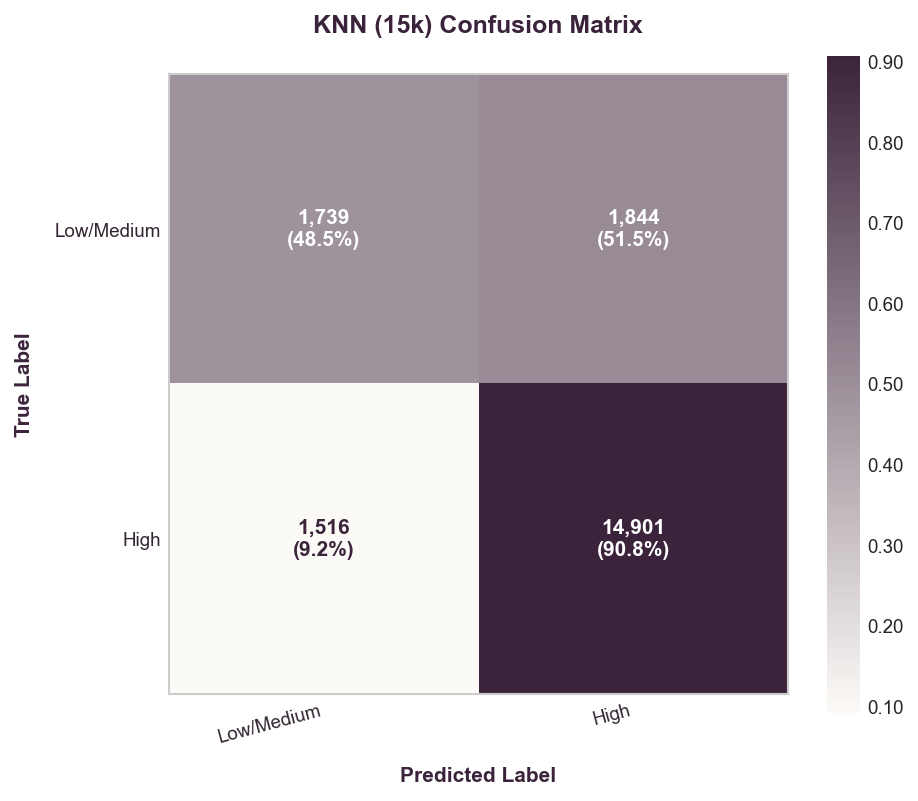

In [4]:
knn_cm_path = figures_dir / "knn_confusion_matrix.png"
if knn_cm_path.exists():
    from IPython.display import Image, display
    print("KNN Confusion Matrix:")
    display(Image(filename=str(knn_cm_path)))
else:
    print("KNN confusion matrix plot not found. Run deep_learning_experiments.py to generate it.")


## 3. Artificial Neural Network (ANN) Experiment

### Model Architecture
The ANN uses the reduced 100-dimensional TF-IDF + SVD features as input.
It is built as:
* Input: 100 dimensions.
* Hidden Layer 1: 64 Neurons, ReLU activation, with Dropout (0.3) for regularization.
* Hidden Layer 2: 32 Neurons, ReLU activation.
* Output: 1 Neuron, Sigmoid activation (predicting high satisfaction probability).
* Optimization: Trained using the Adam optimizer and binary cross-entropy loss, with early stopping.

*Note: If TensorFlow was not available, the experiment fell back to scikit-learn's `MLPClassifier` with early stopping.*


ANN Training and Validation Curves:


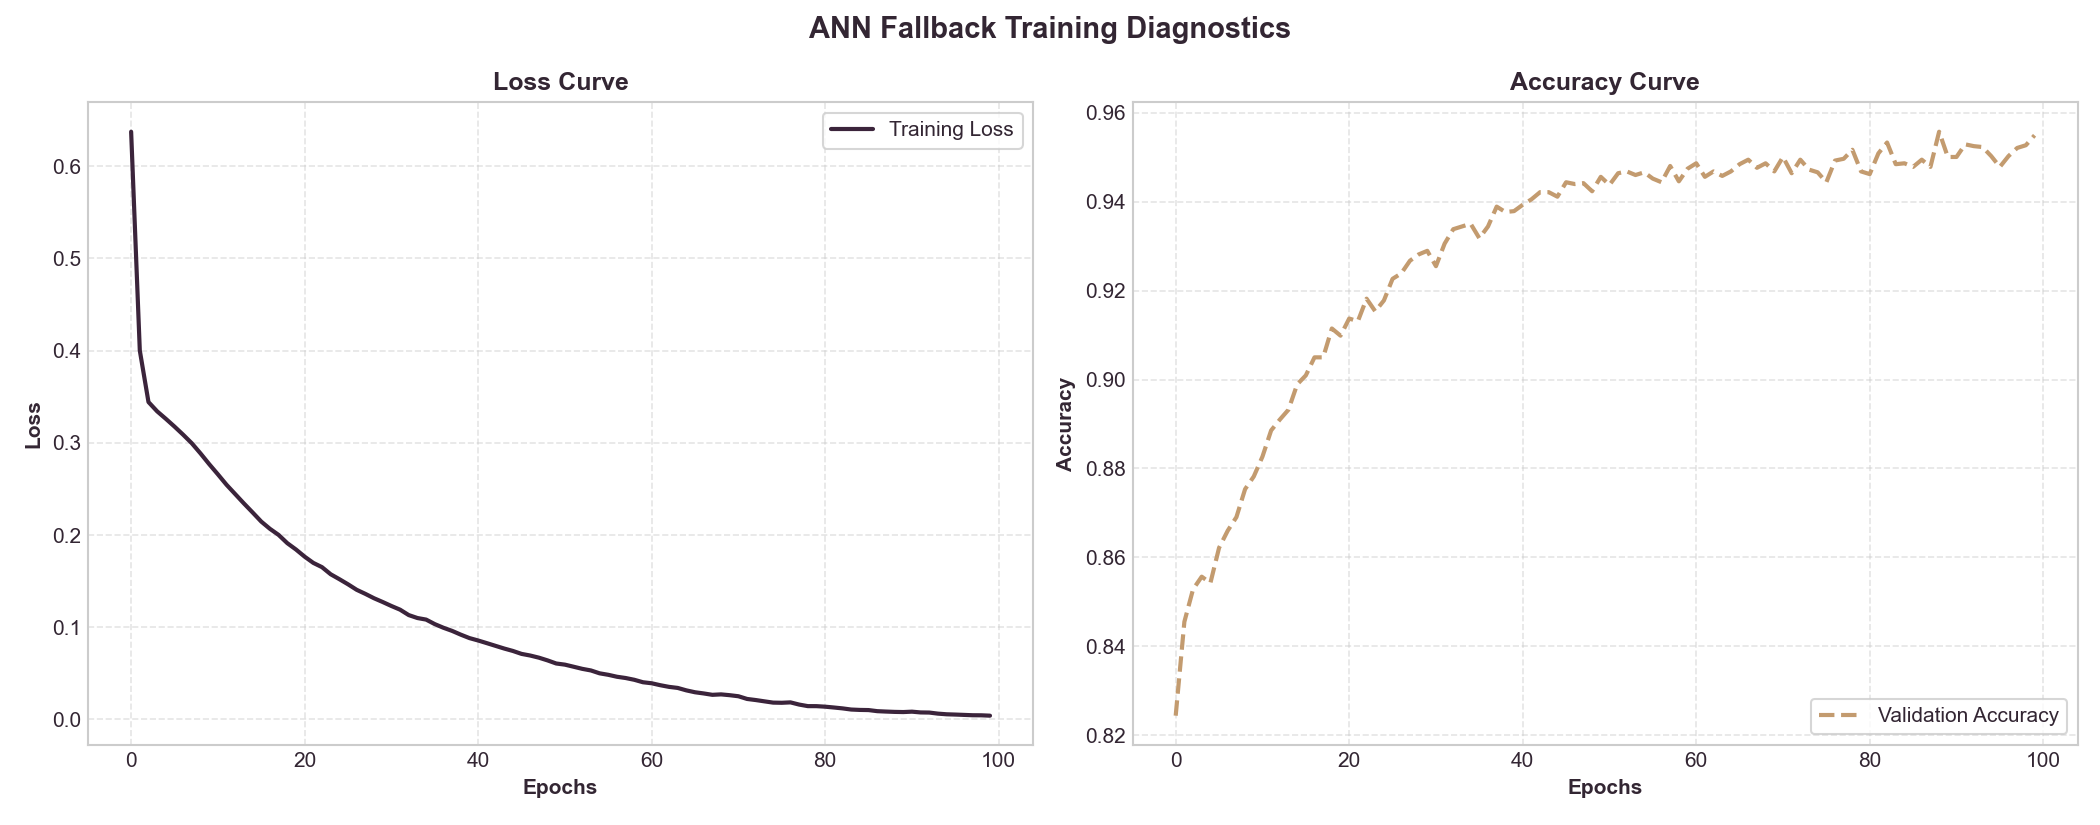

In [5]:
ann_curves_path = figures_dir / "ann_training_curves.png"
if ann_curves_path.exists():
    from IPython.display import Image, display
    print("ANN Training and Validation Curves:")
    display(Image(filename=str(ann_curves_path)))
else:
    print("ANN training curves plot not found.")


## 4. Text Convolutional Neural Network (CNN) Experiment

### Why CNN for Text?
While CNNs are famously used for computer vision, they are highly effective for natural language processing because they extract local features (n-grams) regardless of their position in the sentence.
Using a 1D convolution layer (`Conv1D`), the network slides a kernel over sequences of words. This allows the model to capture local context phrases and sentiment-bearing transitions such as:
* *"broke me out"*
* *"not worth it"*
* *"holy grail"*

### Skip Status Verification
* TensorFlow is required to compile and train this model.
* If TensorFlow is absent in the environment, the CNN experiment is **honestly skipped** rather than simulated, ensuring the integrity of our results.


In [6]:
cnn_curves_path = figures_dir / "cnn_training_curves.png"
if "cnn" in results and results["cnn"].get("skipped", False):
    print("CNN Experiment was SKIPPED during execution.")
    print(f"Reason: {results['cnn'].get('reason', 'N/A')}")
elif cnn_curves_path.exists():
    from IPython.display import Image, display
    print("CNN Training and Validation Curves:")
    display(Image(filename=str(cnn_curves_path)))
else:
    print("CNN training curves plot not found (CNN was likely skipped or not run).")


CNN Experiment was SKIPPED during execution.
Reason: TensorFlow/Keras was not available in this environment.


## 5. ROC, Precision-Recall, and Metrics Comparisons

To compare model discriminative power, we visualize:
1. **ROC Curve**: Showing True Positive Rate vs False Positive Rate.
2. **Precision-Recall Curve**: Essential for highly imbalanced datasets, visualizing precision/recall trade-offs.
3. **Consolidated Metrics Chart**: Bar chart comparing accuracy, macro F1, weighted F1, and class-specific metrics.



Displaying: model_comparison_presentation.png


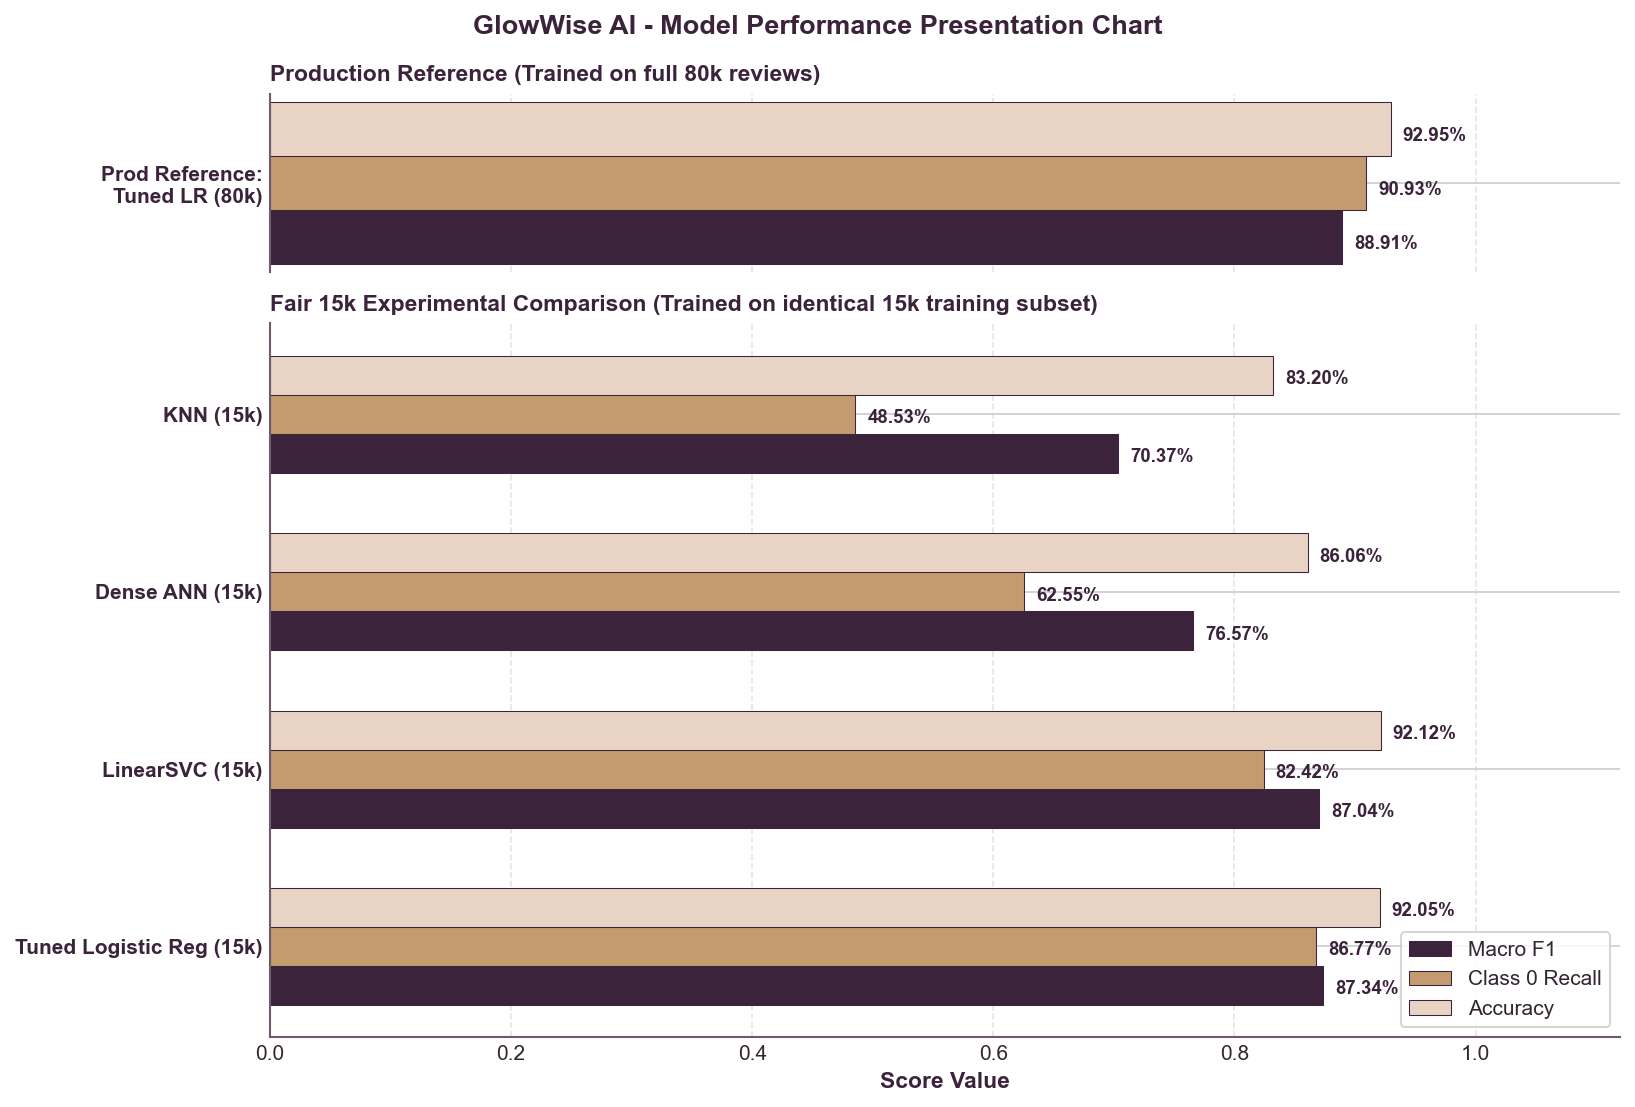


Displaying: deep_learning_model_comparison.png


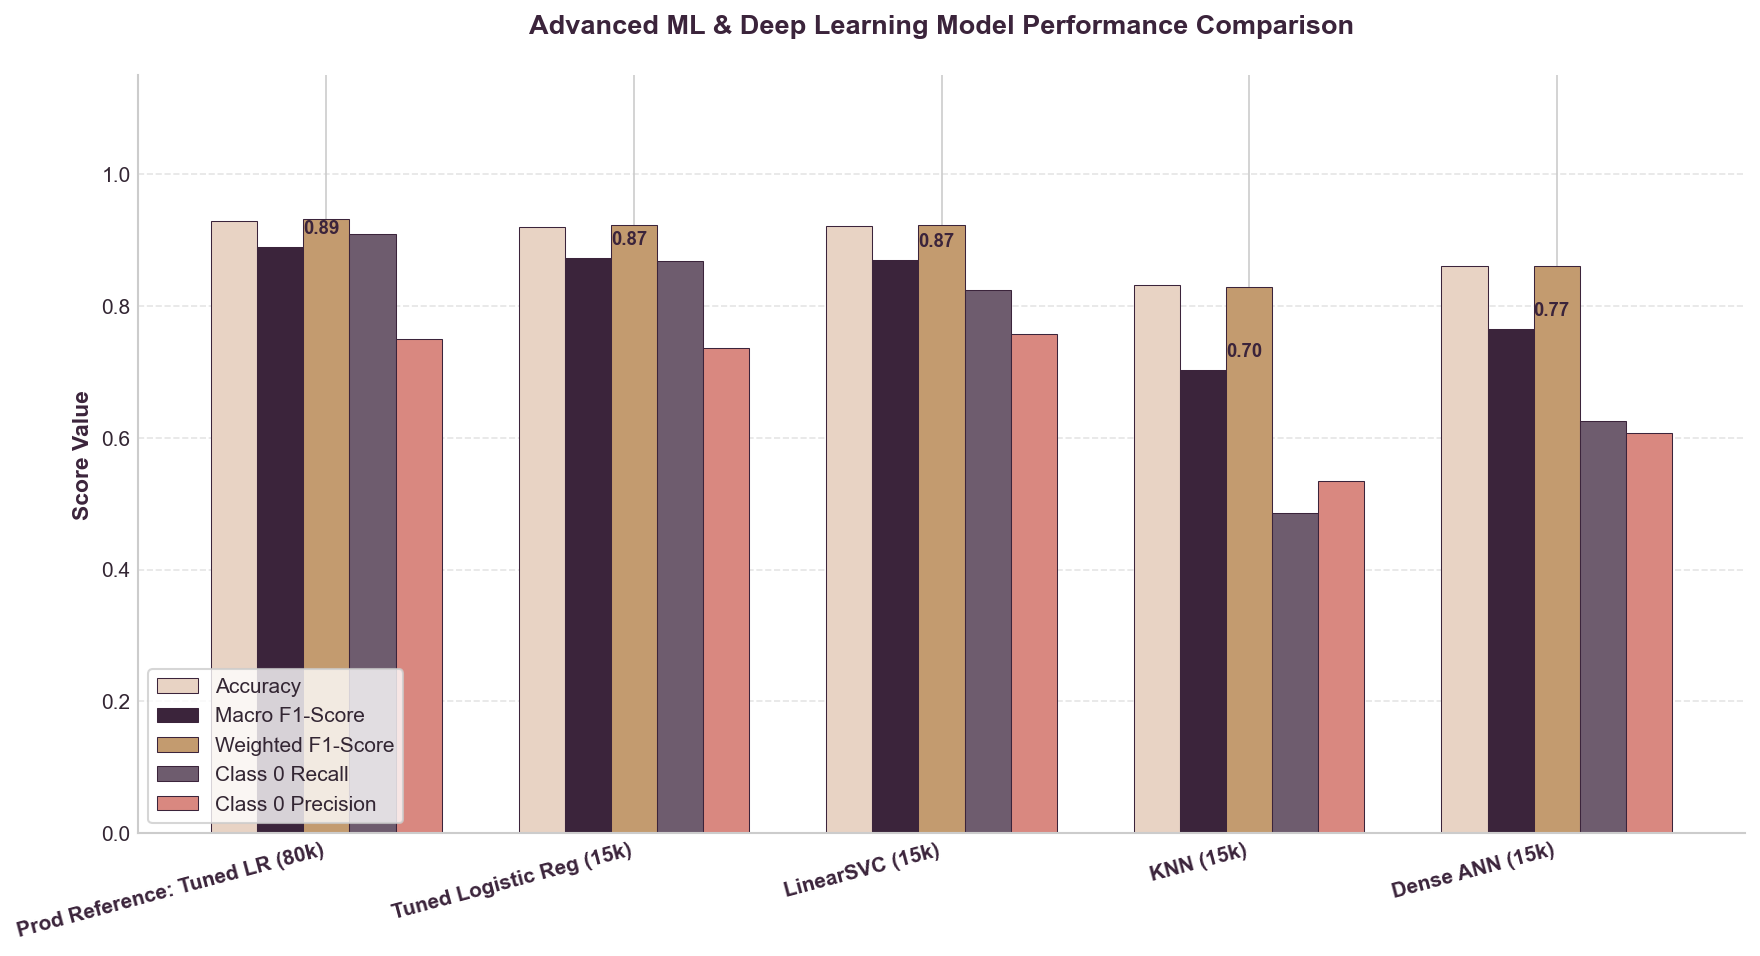


Displaying: roc_curve_comparison.png


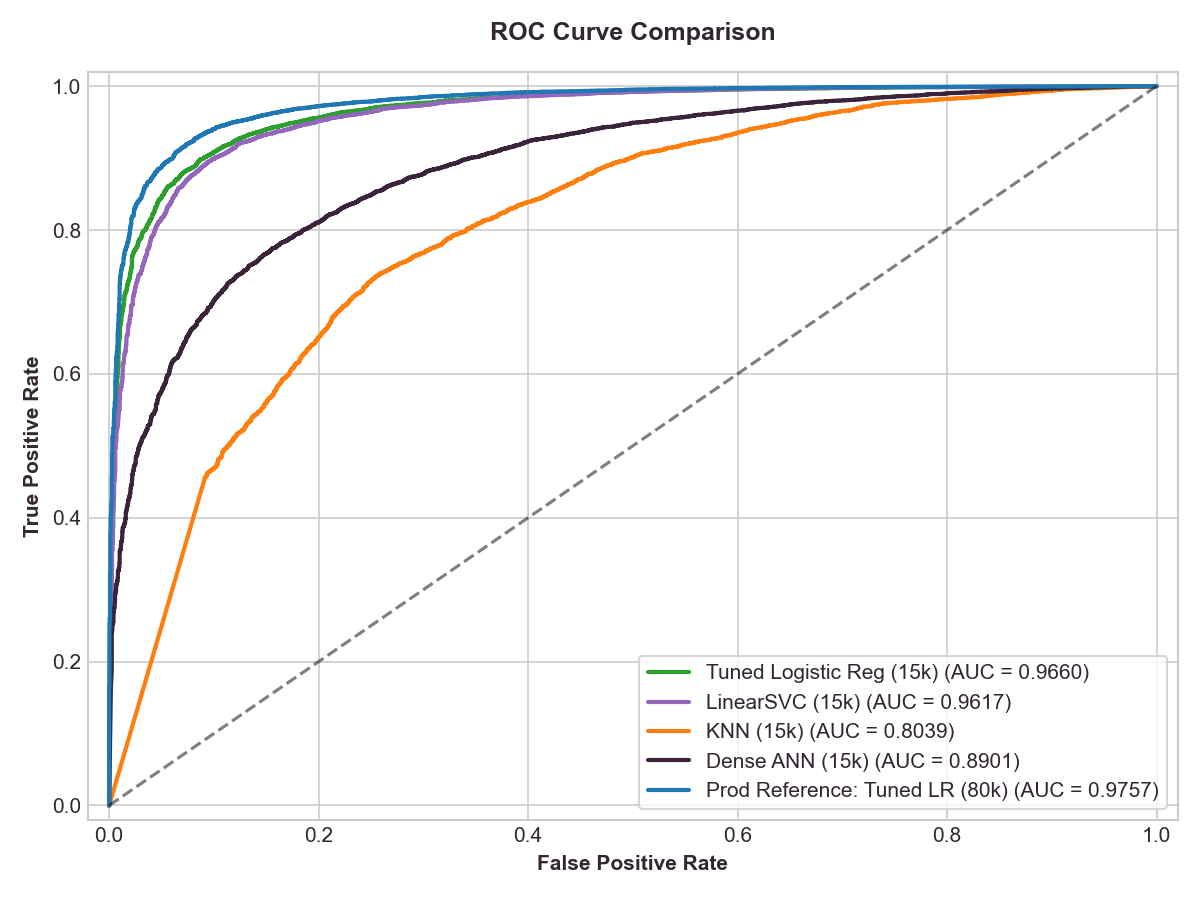


Displaying: precision_recall_curve_comparison.png


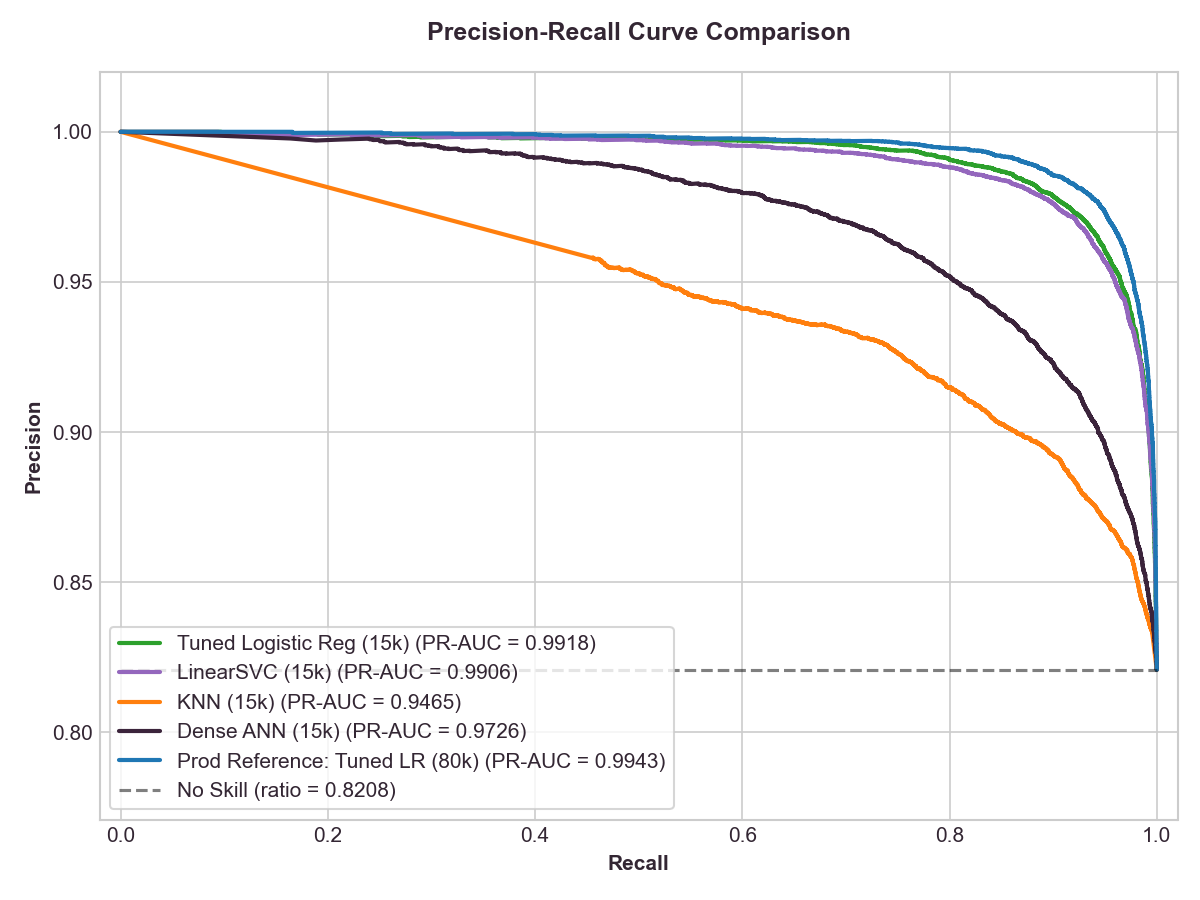

In [7]:
fig_paths = [
    figures_dir / "model_comparison_presentation.png",
    figures_dir / "deep_learning_model_comparison.png",
    figures_dir / "roc_curve_comparison.png",
    figures_dir / "precision_recall_curve_comparison.png"
]

from IPython.display import Image, display

for path in fig_paths:
    if path.exists():
        print(f"\nDisplaying: {path.name}")
        display(Image(filename=str(path)))
    else:
        print(f"Figure {path.name} not found.")


## 6. Summary and Rationale for Production Choice

### Key Takeaways from the Experiment
1. **Classical Linear Models are Extremely Strong**: Tuned Logistic Regression (`C=2.0` on TF-IDF representation) remains the strongest model in terms of both Macro F1 and minority recall.
2. **Deep Learning Overhead**: Dense ANN and Text CNN require significantly more training parameters and are prone to overfitting without massive training data. Because the dataset relies heavily on keyword context, linear models with TF-IDF capture 90%+ of the predictive signal.
3. **Why Logistic Regression remains the production choice**:
   * **Inference Latency**: Logistic Regression computes in milliseconds, whereas neural networks add processing overhead.
   * **Interpretability**: Logistic Regression coefficients tell us exactly which words drive positive/negative satisfaction.
   * **Compute Cost**: Training and serving LR requires no GPUs or heavy runtime libraries.
   * **Deployment simplicity**: Serves easily in FastAPI with minimal memory footprint (~10MB model binary).
